In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/House_Rent_Dataset.csv')

In [3]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [4]:
df['Area Locality'].nunique()

2235

In [5]:
df = df.drop(['Posted On', 'Area Locality'], axis=1)

In [6]:
df.head()

,BHK,Rent,Size,Floor,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,Ground out of 2,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,1 out of 3,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,1 out of 3,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,800,1 out of 2,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,850,1 out of 2,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [7]:
df['Floor'].unique()

array(['Ground out of 2', '1 out of 3', '1 out of 2', 'Ground out of 1',
       'Ground out of 4', '1 out of 4', '1 out of 1', 'Ground out of 3',
       '2 out of 3', '4 out of 5', '2 out of 2', '2 out of 5',
       '4 out of 14', '3 out of 3', '5 out of 5', '4 out of 4',
       '7 out of 8', '2 out of 4', '3 out of 4', '1 out of 5',
       '8 out of 5', 'Ground out of 6', '2 out of 1',
       'Upper Basement out of 4', 'Ground out of 5', '3 out of 5',
       '11 out of 19', '5 out of 10', '11 out of 14',
       'Lower Basement out of 2', '2 out of 7', '4 out of 10',
       '7 out of 10', '2 out of 13', '6 out of 7', '4 out of 7',
       '14 out of 14', '43 out of 78', '2 out of 8', '13 out of 18',
       '5 out of 12', '18 out of 24', '3 out of 7', '17 out of 31',
       '11 out of 21', '7 out of 19', '14 out of 23', '9 out of 20',
       'Upper Basement out of 9', '19 out of 24', '3 out of 21',
       '1 out of 22', '8 out of 8', '6 out of 12', '4 out of 58',
       'Upper Basement o

In [8]:
split_floors = df['Floor'].str.split('out of', expand=True)

df['total_floors'] = pd.to_numeric(split_floors[1].str.strip(), errors='coerce')

df['floor_level'] = split_floors[0].str.strip()

df['floor_level'] = pd.to_numeric(df['floor_level'], errors='coerce')

df['floor_level'] = df['floor_level'].fillna(0).astype(int)

df['total_floors'] = df['total_floors'].fillna(df['total_floors'].median()).astype(int)

df = df.drop('Floor', axis=1)

print(df['floor_level'].unique()[:10])

[ 0  1  2  4  3  5  7  8 11  6]


In [9]:
df.head()

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,total_floors,floor_level
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,2,0
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,3,1
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,3,1
3,2,10000,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,2,1
4,2,7500,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner,2,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   BHK                4746 non-null   int64 
 1   Rent               4746 non-null   int64 
 2   Size               4746 non-null   int64 
 3   Area Type          4746 non-null   object
 4   City               4746 non-null   object
 5   Furnishing Status  4746 non-null   object
 6   Tenant Preferred   4746 non-null   object
 7   Bathroom           4746 non-null   int64 
 8   Point of Contact   4746 non-null   object
 9   total_floors       4746 non-null   int64 
 10  floor_level        4746 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 408.0+ KB


In [11]:
df['floor_level'].unique()

array([ 0,  1,  2,  4,  3,  5,  7,  8, 11,  6, 14, 43, 13, 18, 17,  9, 19,
       60, 34, 12, 26, 25, 53, 16, 10, 39, 32, 47, 28, 20, 15, 65, 40, 37,
       22, 21, 30, 35, 33, 44, 41, 46, 27, 45, 48, 50, 24, 23, 29, 49, 36,
       76])

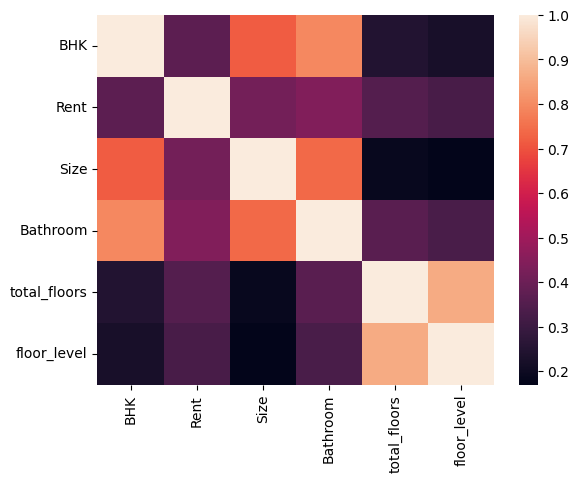

In [12]:
sns.heatmap(df.corr(numeric_only=True));

<Axes: xlabel='Rent', ylabel='floor_level'>

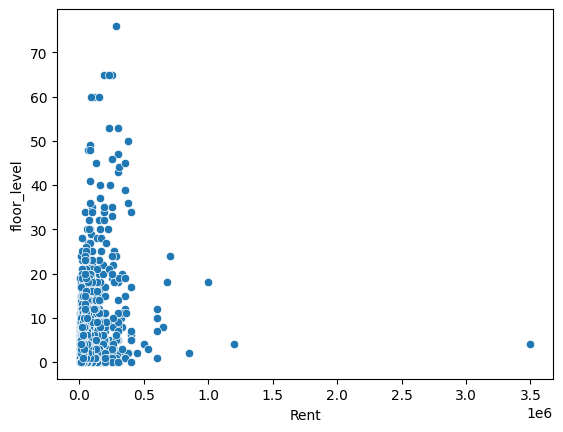

In [13]:
sns.scatterplot(x='Rent', y='floor_level', data=df)

In [14]:
df[df['Rent'] > 3_000_000]

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,total_floors,floor_level
1837,3,3500000,2500,Carpet Area,Bangalore,Semi-Furnished,Bachelors,3,Contact Agent,4,4


In [15]:
df = df.drop(1837)

In [16]:
df[df['Rent'] > 800_000]

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,total_floors,floor_level
827,4,1000000,3064,Carpet Area,Mumbai,Semi-Furnished,Family,4,Contact Agent,45,18
1001,4,1200000,5000,Carpet Area,Mumbai,Semi-Furnished,Bachelors/Family,4,Contact Agent,15,4
1329,4,850000,3200,Carpet Area,Mumbai,Furnished,Bachelors/Family,4,Contact Agent,4,2


In [17]:
df = df.drop([827, 1001, 1329])

<Axes: xlabel='Rent', ylabel='total_floors'>

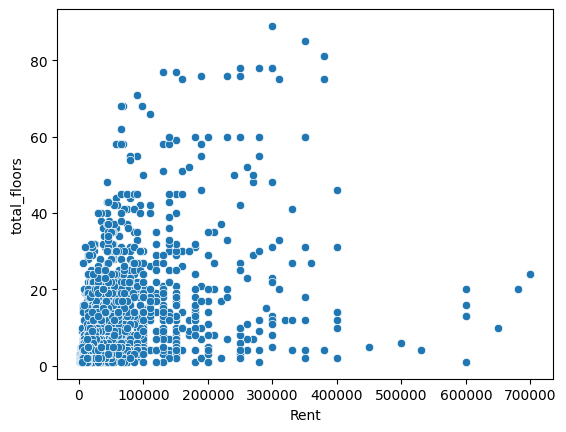

In [18]:
sns.scatterplot(x='Rent', y='total_floors', data=df)

In [19]:
df[(df['Rent']>=500_000) & (df['total_floors'] < 40)]

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,total_floors,floor_level
726,4,600000,2500,Carpet Area,Mumbai,Semi-Furnished,Bachelors/Family,4,Contact Agent,13,12
792,5,600000,3200,Carpet Area,Mumbai,Semi-Furnished,Bachelors/Family,5,Contact Agent,16,10
1023,5,500000,3900,Carpet Area,Mumbai,Furnished,Bachelors/Family,5,Contact Agent,6,4
1319,5,650000,3000,Carpet Area,Mumbai,Semi-Furnished,Bachelors/Family,5,Contact Agent,10,8
1384,5,600000,4500,Carpet Area,Mumbai,Furnished,Bachelors,5,Contact Agent,20,7
1459,4,700000,3200,Carpet Area,Mumbai,Furnished,Bachelors/Family,4,Contact Agent,24,24
1484,4,680000,1962,Carpet Area,Mumbai,Semi-Furnished,Bachelors/Family,5,Contact Agent,20,18
2750,4,530000,4000,Carpet Area,Delhi,Semi-Furnished,Bachelors/Family,5,Contact Agent,4,3
3656,2,600000,950,Carpet Area,Chennai,Unfurnished,Bachelors,2,Contact Owner,1,1


In [20]:
df = df.drop([3656, 1484, 726, 792, 1023, 1319, 1384, 1459, 2750])

In [21]:
df[(df['Rent']>=500_000) & (df['total_floors'] < 40)]

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,total_floors,floor_level


<Axes: xlabel='Rent', ylabel='Bathroom'>

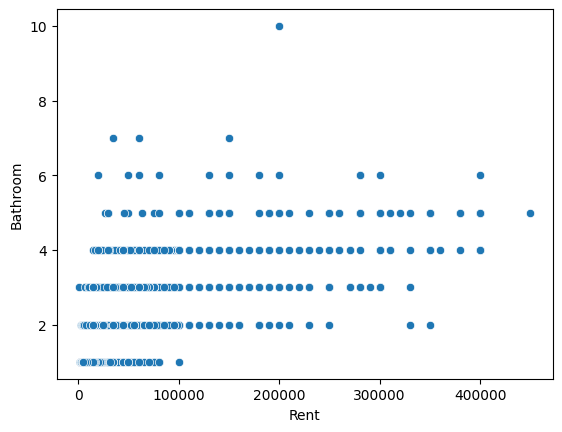

In [22]:
sns.scatterplot(x='Rent', y='Bathroom', data=df)

In [23]:
df[df['Bathroom'] > 9]

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,total_floors,floor_level
4185,1,200000,8000,Super Area,Hyderabad,Unfurnished,Bachelors/Family,10,Contact Owner,4,0


In [24]:
df = df.drop(4185)

<Axes: xlabel='Rent', ylabel='Size'>

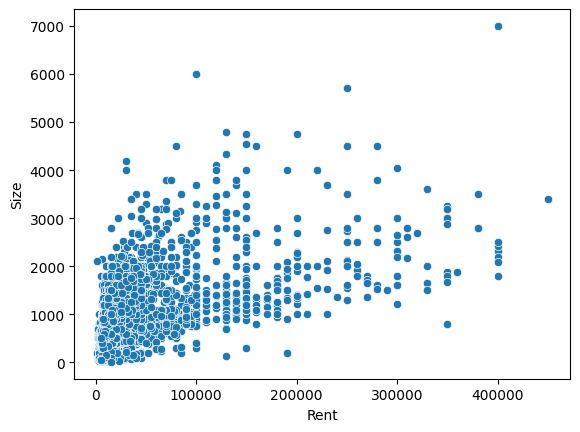

In [25]:
sns.scatterplot(x='Rent', y='Size', data=df)

In [26]:
df[df['Size']>5800]

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,total_floors,floor_level
3622,5,100000,6000,Super Area,Chennai,Semi-Furnished,Bachelors/Family,4,Contact Agent,12,9
4457,4,400000,7000,Carpet Area,Hyderabad,Semi-Furnished,Bachelors/Family,6,Contact Agent,2,0


In [27]:
df = df.drop([3622, 4457])

<Axes: xlabel='Rent', ylabel='BHK'>

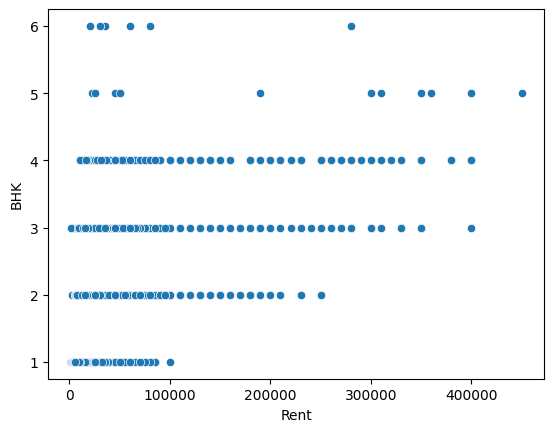

In [28]:
sns.scatterplot(x='Rent', y='BHK', data=df)

In [29]:
df[(df['BHK'] == 6) & (df['Rent'] < 200_000)]

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,total_floors,floor_level
83,6,20000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,2,Contact Owner,1,1
3584,6,60000,1800,Super Area,Chennai,Furnished,Bachelors/Family,6,Contact Owner,3,1
4350,6,60000,2800,Super Area,Hyderabad,Furnished,Bachelors/Family,7,Contact Owner,3,0
4479,6,20000,2400,Super Area,Hyderabad,Unfurnished,Family,4,Contact Owner,1,0
4518,6,35000,3400,Super Area,Hyderabad,Unfurnished,Bachelors/Family,7,Contact Owner,2,0
4648,6,80000,4500,Super Area,Hyderabad,Semi-Furnished,Bachelors/Family,6,Contact Owner,2,1
4696,6,30000,4200,Super Area,Hyderabad,Semi-Furnished,Bachelors/Family,5,Contact Owner,2,0


In [30]:
df = df.drop([83, 3584, 4350, 4479, 4518, 4648, 4696])

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

In [32]:
X = df.drop('Rent', axis=1)

In [33]:
y = df['Rent']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104)

In [35]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

In [36]:
num_features

['BHK', 'Size', 'Bathroom', 'total_floors', 'floor_level']

In [37]:
cat_features

['Area Type',
 'City',
 'Furnishing Status',
 'Tenant Preferred',
 'Point of Contact']

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ],
    remainder='passthrough'
) 

In [39]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', ElasticNetCV(cv=10, l1_ratio=[.1, .5, .7,.9, .95, .99, 1.0]))
])

In [40]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [41]:
y_pred = pipe.predict(X_test)
y_train_pred = pipe.predict(X_train)

In [42]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение alpha: 101.28186594482706
Лучшее значение l1_ratio: 1.0


In [43]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)

In [44]:
MAE

9019.307457551029

In [45]:
MSE

402945434.78980273

In [46]:
RMSE

np.float64(20073.500810516405)

In [47]:
r2_train

0.80941287445998

In [48]:
r2_test

0.7494065790676167

In [49]:
df['Rent'].mean()

np.float64(32408.19817912344)

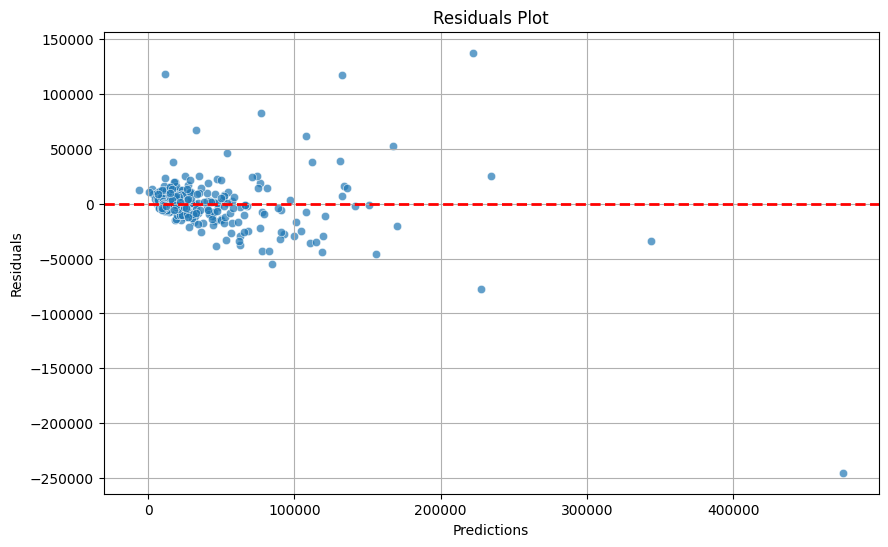

In [50]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title('Residuals Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.grid(True)

In [51]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [52]:
y_pred_full = pipe.predict(X)

In [53]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_final_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение alpha: 150.5055176379028
Лучшее значение l1_ratio: 1.0


In [54]:
r2_full = r2_score(y, y_pred_full)

In [55]:
r2_full

0.8022198894667326

In [56]:
houses = {
    'BHK': [1, 3],
    'Size': [450, 1800],
    'Area Type': ['Super Area', 'Carpet Area'],
    'City': ['Kolkata', 'Mumbai'],
    'Furnishing Status': ['Unfurnished', 'Furnished'],
    'Tenant Preferred': ['Bachelors', 'Family'],
    'Bathroom': [1, 3],
    'Point of Contact': ['Contact Owner', 'Contact Agent'],
    'total_floors': [3, 35],
    'floor_level': [1, 22]
}

In [57]:
houses_df = pd.DataFrame(houses)

In [58]:
houses_df

,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,total_floors,floor_level
0,1,450,Super Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner,3,1
1,3,1800,Carpet Area,Mumbai,Furnished,Family,3,Contact Agent,35,22


In [59]:
pipe.predict(houses_df)

array([  8279.18399412, 190118.89993492])

In [65]:
import json
import os

advanced_report = {
    "project": "House Rent Prediction",
    "model": "ElasticNetCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "alpha": best_model.alpha_,
        "l1_ratio": best_model.l1_ratio_,
        "cv": best_model.cv
    },
    "final_parameters": {
        "alpha": best_final_model.alpha_,
        "l1_ratio":  best_final_model.l1_ratio_,
        "cv": best_final_model.cv
    },
    "metrics": {
        "RMSE": RMSE,
        "MAE": MAE,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "R2_full": r2_full,
        "Mean_House_Rent": df['Rent'].mean()
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [61]:
from joblib import dump, load

In [62]:
dump(pipe, "model/house_rent_predict_elastic_net_cv_model_2026_v1.pkl")

['model/house_rent_predict_elastic_net_cv_model_2026_v1.pkl']

In [63]:
loaded_pipe = load('model/house_rent_predict_elastic_net_cv_model_2026_v1.pkl')

In [64]:
loaded_pipe.predict(houses_df)

array([  8279.18399412, 190118.89993492])